In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [80]:
complaint_df = pd.read_csv("datatset_consumer_complaints.csv")

In [15]:
complaint_df.head()

,ID,Company,Product,Issue,State,Submitted via,Date received,Date resolved,Timely response?,Consumer disputed?,state name,Date received.1,Date resolved.1,Resolution time(in days),Year,QTR (US FLY)
0,1615767,PHH Mortgage,Mortgage,"Loan servicing, payments, escrow account",FL,Web,10/20/2015,10/20/2015,Yes,No,Florida,10/20/2015,10/20/2015,0,2015,Q4
1,654223,Ocwen,Mortgage,"Loan servicing, payments, escrow account",NC,Web,3/1/2014,3/1/2014,Yes,No,North Carolina,1/3/2014,1/3/2014,0,2014,Q1
2,1143398,"Southwest Credit Systems, L.P.",Debt collection,"Loan modification,collection,foreclosure",MO,Web,4/12/2014,4/12/2014,Yes,No,Missouri,12/4/2014,12/4/2014,0,2014,Q4
3,1303679,"Continental Finance Company, LLC",Credit card,Billing statement,WA,Web,03/26/2015,03/26/2015,Yes,No,Washington,3/26/2015,3/26/2015,0,2015,Q1
4,1627370,Experian,Credit reporting,Unable to get credit report/credit score,VA,Web,10/27/2015,10/27/2015,Yes,No,Virginia,10/27/2015,10/27/2015,0,2015,Q4


In [17]:
complaint_df.shape

(14000, 16)

In [19]:
#check for null
complaint_df.isnull().sum()

 ID                           0
Company                       0
Product                       0
Issue                         0
State                       110
Submitted via                 0
Date received                 0
Date resolved                 0
Timely response?              0
Consumer disputed?            0
state name                  157
Date received.1               0
Date resolved.1               0
Resolution time(in days)      0
Year                          0
QTR (US FLY)                  0
dtype: int64

Visualizations/Exploring the data

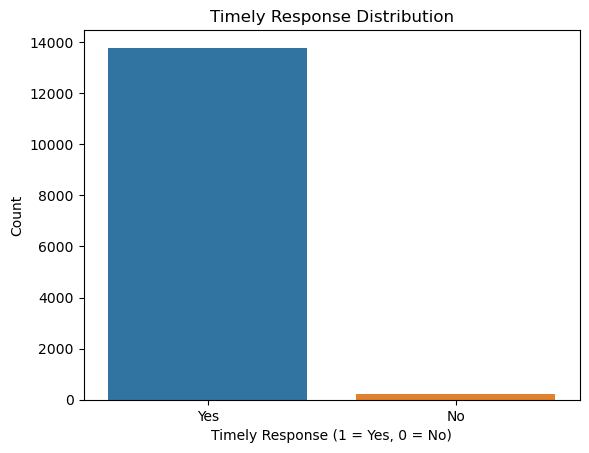

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot of timely response count
sns.countplot(data=complaint_df, x='Timely response?')
plt.title("Timely Response Distribution")
plt.xlabel("Timely Response (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

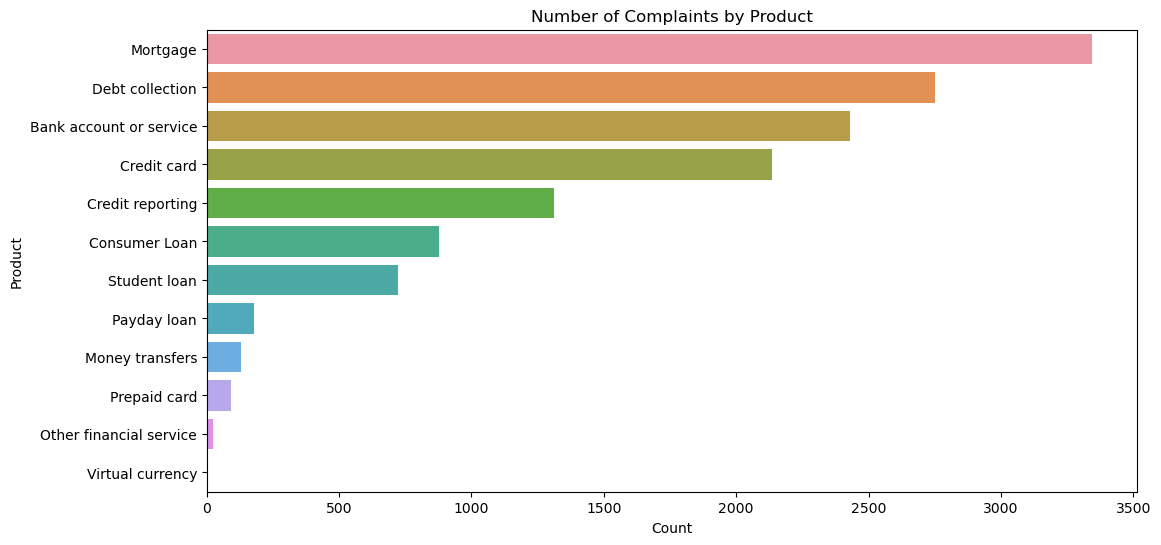

In [52]:
plt.figure(figsize=(12, 6))
sns.countplot(data=complaint_df, y='Product', order=complaint_df['Product'].value_counts().index)
plt.title("Number of Complaints by Product")
plt.xlabel("Count")
plt.ylabel("Product")
plt.show()

C:\Users\my-lo\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


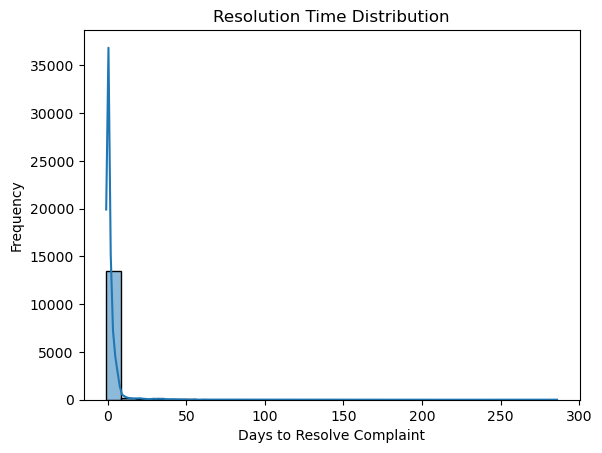

In [58]:
sns.histplot(complaint_df['Resolution time(in days)'], bins=30, kde=True)
plt.title("Resolution Time Distribution")
plt.xlabel("Days to Resolve Complaint")
plt.ylabel("Frequency")
plt.show()

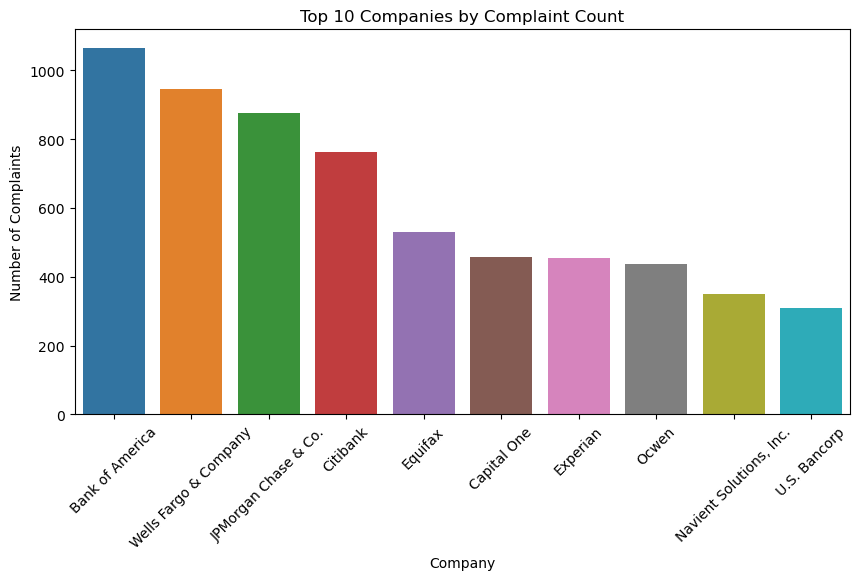

In [60]:
top_companies = complaint_df['Company'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_companies.index, y=top_companies.values)
plt.title("Top 10 Companies by Complaint Count")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

Cleaning the data to prep the data

In [82]:
# Removes any leading/trailing whitespaces from column names
complaint_df.columns = complaint_df.columns.str.strip()

In [84]:
# Convert Date columns to datetime
complaint_df['Date received'] = pd.to_datetime(complaint_df['Date received'], errors='coerce')
complaint_df['Date resolved'] = pd.to_datetime(complaint_df['Date resolved'], errors='coerce')

In [86]:
# Converting timely response to binary 1/0
complaint_df['Timely response?'] = complaint_df['Timely response?'].map({'Yes': 1, 'No': 0})

In [88]:
#Looking back, there are some missing values in the state. I will fill the  missing values with NA
complaint_df['State'] = complaint_df['State'].fillna('NA')

In [90]:
#Removing unncessary columns
complaint_df = complaint_df.drop(columns=['ID', 'Consumer disputed?', 'state name', 'Date received.1', 'Date resolved.1', 'Year', 'QTR (US FLY)'])

In [92]:
complaint_df.head()

,Company,Product,Issue,State,Submitted via,Date received,Date resolved,Timely response?,Resolution time(in days)
0,PHH Mortgage,Mortgage,"Loan servicing, payments, escrow account",FL,Web,2015-10-20,2015-10-20,1,0
1,Ocwen,Mortgage,"Loan servicing, payments, escrow account",NC,Web,2014-03-01,2014-03-01,1,0
2,"Southwest Credit Systems, L.P.",Debt collection,"Loan modification,collection,foreclosure",MO,Web,2014-04-12,2014-04-12,1,0
3,"Continental Finance Company, LLC",Credit card,Billing statement,WA,Web,2015-03-26,2015-03-26,1,0
4,Experian,Credit reporting,Unable to get credit report/credit score,VA,Web,2015-10-27,2015-10-27,1,0


In [94]:
complaint_df.shape

(14000, 9)

In [96]:
complaint_df.isnull().sum()

Company                     0
Product                     0
Issue                       0
State                       0
Submitted via               0
Date received               0
Date resolved               0
Timely response?            0
Resolution time(in days)    0
dtype: int64

Modeling

Logistic regression 

In [100]:
features = ['Resolution time(in days)', 'Product', 'Issue', 'State', 'Submitted via', 'Company']
target = 'Timely response?'

complaint_df_encoded = pd.get_dummies(complaint_df[features], drop_first=True)

# One-hot encode
complaint_df_encoded['Resolution time(in days)'] = complaint_df['Resolution time(in days)']

In [102]:
# Defining X and y
X = complaint_df_encoded
y = complaint_df[target]

In [104]:
# Train/Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [106]:
# Logistic regerssion
logreg= LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [107]:
y_pred = logreg.predict(X_test)


In [110]:
table = classification_report(y_test, y_pred,output_dict=True)

In [112]:
disp_classification = pd.DataFrame(table).transpose()
disp_classification

,precision,recall,f1-score,support
0,0.000000,0.000000,0.000000,56.000000
1,0.979993,0.999636,0.989717,2744.000000
accuracy,0.979643,0.979643,0.979643,0.979643
macro avg,0.489996,0.499818,0.494858,2800.000000
weighted avg,0.960393,0.979643,0.969922,2800.000000


In [114]:
# Logistic regression with class_weight
logreg_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [115]:
y_pred_bal = logreg_balanced.predict(X_test)


In [116]:
table2 = classification_report(y_test, y_pred_bal,output_dict=True)

In [117]:
disp_classification2 = pd.DataFrame(table2).transpose()
disp_classification2

,precision,recall,f1-score,support
0,0.080292,0.392857,0.133333,56.000000
1,0.986540,0.908163,0.945731,2744.000000
accuracy,0.897857,0.897857,0.897857,0.897857
macro avg,0.533416,0.650510,0.539532,2800.000000
weighted avg,0.968415,0.897857,0.929483,2800.000000


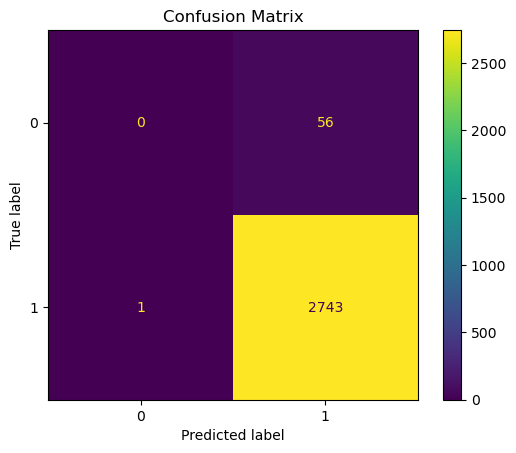

In [118]:
conf_mat=confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
display.plot()
plt.title("Confusion Matrix")
plt.show()

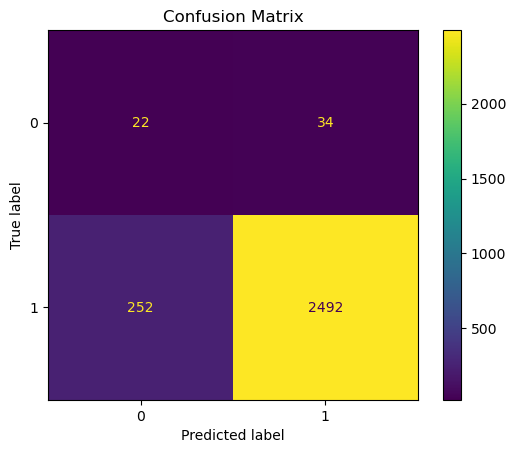

In [119]:
conf_mat=confusion_matrix(y_test, y_pred_bal)
display = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
display.plot()
plt.title("Confusion Matrix")
plt.show()

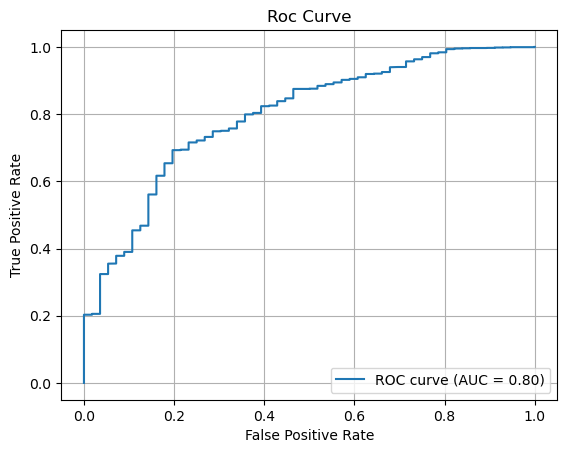

In [120]:
y_proba_logreg = logreg_balanced.predict_proba(X_test)[:, 1]
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
auc_logreg = roc_auc_score(y_test, y_proba_logreg)

plt.figure()
plt.plot(fpr_logreg, tpr_logreg, label=f'ROC curve (AUC = {auc_logreg:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

XGboost

In [128]:
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [130]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]


In [132]:
classification_report(y_test, y_pred_xgb)

'              precision    recall  f1-score   support\n\n           0       1.00      0.02      0.04        56\n           1       0.98      1.00      0.99      2744\n\n    accuracy                           0.98      2800\n   macro avg       0.99      0.51      0.51      2800\nweighted avg       0.98      0.98      0.97      2800\n'

In [134]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

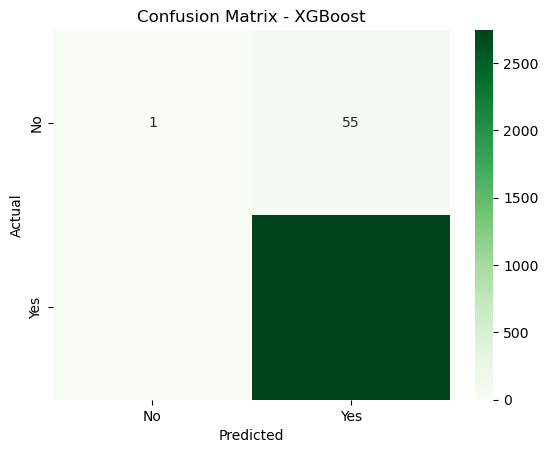

In [136]:
sns.heatmap(cm_xgb,annot=True, fmt='d',cmap='Greens',xticklabels=['No', 'Yes'],yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [138]:
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
auc_xgb

0.7449174822990422

XGboost with SMOTE

In [140]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [142]:
model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
model.fit(X_resampled, y_resampled)

C:\Users\my-lo\anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:07:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [144]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [148]:
roc_auc_score(y_test, y_proba)

0.7238032330279051

In [150]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.09      0.20      0.12        56\n           1       0.98      0.96      0.97      2744\n\n    accuracy                           0.94      2800\n   macro avg       0.54      0.58      0.55      2800\nweighted avg       0.97      0.94      0.95      2800\n'

In [152]:
table3 = classification_report(y_test, y_pred,output_dict=True)

In [156]:
disp_classification3 = pd.DataFrame(table3).transpose()
disp_classification3

,precision,recall,f1-score,support
0,0.088710,0.196429,0.122222,56.000000
1,0.983184,0.958819,0.970849,2744.000000
accuracy,0.943571,0.943571,0.943571,0.943571
macro avg,0.535947,0.577624,0.546535,2800.000000
weighted avg,0.965294,0.943571,0.953876,2800.000000
